In [1]:
# MNIST with an MLP, from scratch

# - Step 1: build an MLP from scratch to solve MNIST. Question set: https://fleuret.org/dlc/materials/dlc-practical-3.pdf
# - Step 2: debug your network with backprop ninja and a reference implementation using torch's .backward()
# - Step 3: build the same MLP but will full pytorch code (nn.Linear, etc.)

In [2]:
import math
import torch
from torch import nn
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from utils import load_data

In [4]:
train_input, train_target, test_input, test_target = load_data(one_hot_labels = True, normalize = True)

* Using MNIST
** Reduce the data-set (use --full for the full thing)
** Use 1000 train and 1000 test samples


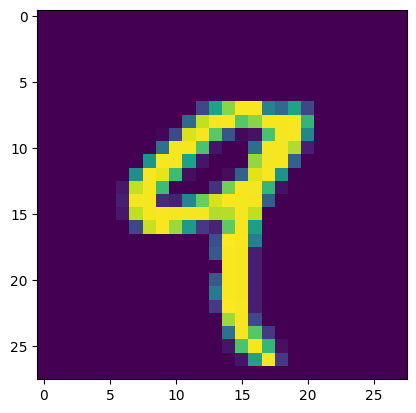

In [5]:
plt.imshow(train_input[4].view((28,28)))
plt.show()

In [6]:
def compute_accuracy (preds, targets):
    """ Computes the accuracy between predictions and targets. Data is expected to be one-hot encoded. """
    _, idx1 = torch.max(preds, dim=1)
    _, idx2 = torch.max(targets, dim=1)
    d = idx1 == idx2
    return d.int().float().mean().item()

In [7]:
# unit test
# this cell should return 0.75
preds = torch.zeros((4,7))
preds[0,1] = 1
preds[1,4] = 1
preds[2,2] = 1
preds[3,6] = 1
targets = torch.zeros((4,7))
targets[0,1] = 1
targets[1,4] = 1
targets[2,2] = 1
targets[3,2] = 1
compute_accuracy(preds, targets)

0.75

In [8]:
def sigma(x):
    return torch.tanh(x)

def dsigma(x):
    tanh = sigma(x)
    return 1-  tanh*tanh

In [9]:
def loss (v,t):
    
    Diff = v-t
    return torch.sum(Diff*Diff)

def dloss(v,t):
    diff = v-t
    return 2*diff

In [10]:
# sanity check
v = torch.randn((3, 6), dtype=torch.float32)
t = torch.randn((3, 6), dtype=torch.float32)
l=loss(v,t)
dloss(v,t)

tensor([[-1.0608,  2.9003, -1.0300, -0.5730,  2.2717, -1.0486],
        [ 0.8911, -4.5804,  4.5311, -1.4916,  2.1673,  1.3700],
        [-3.6306, -1.6733, -6.9816,  0.1510, -0.0124, -3.0988]])

In [11]:
# multiply targets by 0.9 to be in the range of tanh
train_target *= 0.9
test_target *= 0.9

### Step 1: Backprop ninja

In [12]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
# DO NOT MODIFY IT
#
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [13]:
torch.manual_seed(1337)
w1 = torch.randn((784,50))
b1 = torch.randn((50,))
w2 = torch.randn((50,10))
b2 = torch.randn((10,))
parameters = [w1, b1, w2, b2]
for p in parameters:
    p.requires_grad = True

In [14]:
x1 = train_input[:5]
y1 = train_target[:5]
z1 = x1 @ w1 + b1 
h1 = sigma(z1)
z2 = h1 @ w2 + b2
h2 = sigma(z2)
l = loss(h2, y1)
h2.shape, l

(torch.Size([5, 10]), tensor(43.2825, grad_fn=<SumBackward0>))

In [15]:
# Force pytorch to retain grade for intermediate nodes and reset grad for parameters
# DO NOT MODIFY THIS CODE
#
others = [h2,z2,h1,z1]
for p in parameters:
    p.grad = None
for t in others:
    t.retain_grad()
l.backward()
print(f'loss={l}')

loss=43.28252410888672


In [16]:
b2.grad.shape

torch.Size([10])

In [17]:
# here we compare our gradient to the reference gradient computed by pytorch
dl = 1.0
dh2 = dloss(h2,y1)
cmp('h2',dh2,h2)
dz2 = dh2 * dsigma(z2)
cmp('z2',dz2, z2)
dw2 = h1.t() @ dz2
cmp('w2',dw2, w2)
db2 = dz2.sum(dim = 0)
cmp('b2',db2, b2)
dh1 = dz2 @ w2.t() 
cmp('h1',dh1, h1)
dz1 = dh1 * dsigma(z1)
cmp('z1', dz1, z1)
dw1 = x1.t() @ dz1
cmp('w1', dw1, w1)
db1 = dz1.sum(dim = 0)
cmp('b1', db1, b1)


h2              | exact: True  | approximate: True  | maxdiff: 0.0
z2              | exact: True  | approximate: True  | maxdiff: 0.0
w2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
h1              | exact: True  | approximate: True  | maxdiff: 0.0
z1              | exact: True  | approximate: True  | maxdiff: 0.0
w1              | exact: True  | approximate: True  | maxdiff: 0.0
b1              | exact: True  | approximate: True  | maxdiff: 0.0


In [18]:
lr = 0.1
with torch.no_grad():
    w1 += -lr * dw1
    b1 += -lr * db1.squeeze()
    w2 += -lr * dw2
    b2 += -lr * db2.squeeze()

In [19]:
l = loss(h2, y1)
l.item()

43.28252410888672

##### Now that we've checked our gradients are correct, we can implement the network

In [20]:
def forward(w1, b1, w2, b2, x):
    z1 = x @ w1 + b1 
    h1 = sigma(z1)
    z2 = h1 @ w2 + b2
    h2 = sigma(z2)
    return z1, h1, z2, h2


In [29]:
def backward(w1, b1, w2, b2, x1, y1, h2, z2, h1, z1):
    dl = 1.0
    dh2 = dloss(h2,y1)
    dz2 = dh2 * dsigma(z2)
    
    dw2 = h1.t() @ dz2
    
    db2 = dz2.sum(dim = 0)
    
    dh1 = dz2 @ w2.t() 
    
    dz1 = dh1 * dsigma(z1)
    
    dw1 = x1.t() @ dz1
    
    db1 = dz1.sum(dim = 0)
    
    return dw1, db1, dw2, db2

In [30]:
def update(w1, b1, w2, b2, dw1, db1, dw2, db2, lr):
    with torch.no_grad():
        w1 += -lr * dw1
        b1 += -lr * db1
        w2 += -lr * dw2
        b2 += -lr * db2
    return w1, b1, w2, b2

In [31]:
def init():
    """ init a network """
    w1 = torch.randn((784,50))
    b1 = torch.randn((50,))
    w2 = torch.randn((50,10))
    b2 = torch.randn((10,))
    return w1, b1, w2, b2

In [32]:
w1, b1, w2, b2 = init()
parameters = [w1, b1, w2, b2]
for p in parameters:
    p.requires_grad_(True)

In [33]:
# main training loop
torch.set_printoptions(linewidth=200)
def train(w1, b1, w2, b2):
    lossi = []
    for step in range(10000):
        xb = train_input
        yb = train_target
        num_samples = xb.shape[0]
        # forward
        z1, h1, z2, h2 = forward(w1, b1, w2, b2, xb)
        lsi = loss(h2, yb)
        # backward
        dw1, db1, dw2, db2 = backward(w1, b1, w2, b2, xb, yb, h2, z2, h1, z1)
        # update
        lr = 0.1 / num_samples if step < 5000 else 0.01 / num_samples
        w1, b1, w2, b2 = update(w1, b1, w2, b2, dw1, db1, dw2, db2, lr)
        if step % 100 == 0: print(f'step = {step}, loss = {lsi}')
        lossi.append(lsi.item())
    # compute accuracy
    _, _, _, preds = forward(w1, b1, w2, b2, train_input)
    train_accuracy = compute_accuracy(preds, train_target)
    _, _, _, preds = forward(w1, b1, w2, b2, test_input)
    test_accuracy = compute_accuracy(preds, test_target)
    print(f'{train_accuracy=}')
    print(f'{test_accuracy=}')
    return lossi

        
    

In [34]:
lossi = train(w1, b1, w2, b2)


step = 0, loss = 9688.7314453125
step = 100, loss = 8069.04736328125
step = 200, loss = 7675.72802734375
step = 300, loss = 7376.5341796875
step = 400, loss = 7130.93603515625
step = 500, loss = 6942.4443359375
step = 600, loss = 6746.2880859375
step = 700, loss = 6521.9853515625
step = 800, loss = 6063.6044921875
step = 900, loss = 5963.626953125
step = 1000, loss = 5760.22021484375
step = 1100, loss = 5336.37890625
step = 1200, loss = 5201.3115234375
step = 1300, loss = 4878.55615234375
step = 1400, loss = 4567.6376953125
step = 1500, loss = 4387.87353515625
step = 1600, loss = 4310.99072265625
step = 1700, loss = 4206.9091796875
step = 1800, loss = 4011.658935546875
step = 1900, loss = 3763.562255859375
step = 2000, loss = 3654.896728515625
step = 2100, loss = 3500.734619140625
step = 2200, loss = 3176.425048828125
step = 2300, loss = 3140.9755859375
step = 2400, loss = 3067.204345703125
step = 2500, loss = 2981.0693359375
step = 2600, loss = 2855.84765625
step = 2700, loss = 2653.2

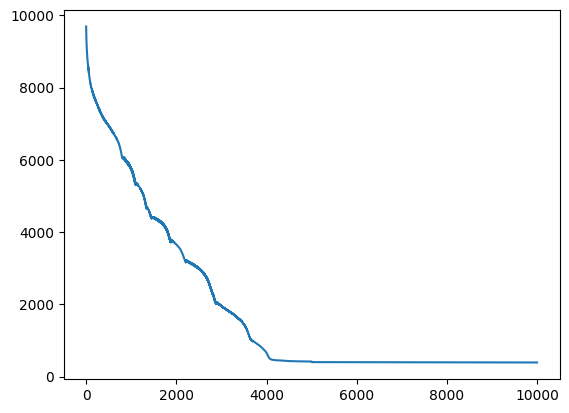

In [35]:
plt.plot(lossi)
plt.show()

### Step 2: Reference implementation using pytorch's .backward()
Nothing to do in Step 2, this code is provided for you as a reference

In [36]:
w1, b1, w2, b2 = init()
parameters = [w1, b1, w2, b2]
for p in parameters:
    p.requires_grad_(True)

In [37]:
# reference code
torch.set_printoptions(linewidth=200)
import torch.nn as F

def train(w1, b1, w2, b2):
    lossi = []
    for step in range(10000):
        xb = train_input
        yb = train_target
        num_samples = xb.shape[0]
        # forward
        z1, h1, z2, h2 = forward(w1, b1, w2, b2, xb)
        xloss = F.MSELoss()
        lsi = xloss(h2, yb) * yb.nelement()
        # backward
        for p in parameters:
            p.grad = None
        lsi.backward()
        # update
        lr = 0.1 / num_samples
        for p in parameters:
            p.data += -lr * p.grad
        if step % 100 == 0: print(f'step = {step}, loss = {lsi}')
        lossi.append(lsi.item())
    # compute accuracy
    _, _, _, preds = forward(w1, b1, w2, b2, train_input)
    train_accuracy = compute_accuracy(preds, train_target)
    _, _, _, preds = forward(w1, b1, w2, b2, test_input)
    test_accuracy = compute_accuracy(preds, test_target)
    print(f'{train_accuracy=}')
    print(f'{test_accuracy=}')
    return lossi

In [38]:
lossi = train(w1, b1, w2, b2)

step = 0, loss = 9982.986328125
step = 100, loss = 8752.978515625
step = 200, loss = 8054.9072265625
step = 300, loss = 7703.55859375
step = 400, loss = 7507.359375
step = 500, loss = 7334.10107421875
step = 600, loss = 7179.89697265625
step = 700, loss = 7045.8876953125
step = 800, loss = 6914.59912109375
step = 900, loss = 6808.95556640625
step = 1000, loss = 6689.76123046875
step = 1100, loss = 6565.46435546875
step = 1200, loss = 6450.25390625
step = 1300, loss = 6320.46484375
step = 1400, loss = 6125.0146484375
step = 1500, loss = 5726.95849609375
step = 1600, loss = 5519.8134765625
step = 1700, loss = 5362.673828125
step = 1800, loss = 5122.689453125
step = 1900, loss = 4519.68701171875
step = 2000, loss = 3752.340576171875
step = 2100, loss = 3514.056396484375
step = 2200, loss = 3131.762939453125
step = 2300, loss = 2740.68115234375
step = 2400, loss = 2559.1064453125
step = 2500, loss = 2469.190673828125
step = 2600, loss = 2340.86279296875
step = 2700, loss = 2069.1220703125


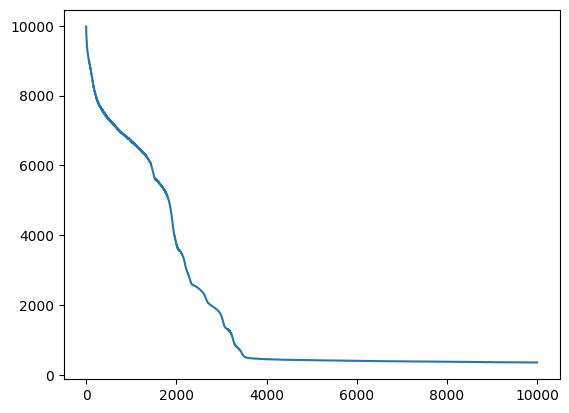

In [39]:
plt.plot(lossi)
plt.show()

### Step 3: Build the same MLP layer but with fully pytorch code (nn.Linear(), etc.)

In [40]:
# network dimensions
n_in = 784
n_hidden = 200
n_out = 10

In [41]:
X_tr, Y_tr = train_input, train_target
X_test, Y_test = test_input, test_target

In [43]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList((
            nn.Linear(784, 50),
            nn.Tanh(),
            nn.Linear(50, 10)
        ))

    def __call__(self, x):
        
        for layer in self.layers:
            x = layer(x)
        return x

    
    def __parameters__(self):
        return [p for layer in self.layers for p in layer.parameters]

model = MLP()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

In [44]:
# training
num_epochs = 10000

for n in range(num_epochs):
    y_pred = model(X_tr)
    loss = loss_fn(y_pred, Y_tr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if n % 1000 == 0: 
        with torch.no_grad():
            # train accuracy
            acc_train = compute_accuracy(y_pred, Y_tr)
            # test accuracy
            y_test_preds = model(X_test)
            acc_test = compute_accuracy(y_test_preds, Y_test)
            print(f'step = {n:6d}\tloss={loss.item():.5f}\taccuracy (train, test): {acc_train:.5f}\t{acc_test:.5f}')




step =      0	loss=0.16891	accuracy (train, test): 0.09700	0.16200
step =   1000	loss=0.00049	accuracy (train, test): 1.00000	0.83800
step =   2000	loss=0.00012	accuracy (train, test): 1.00000	0.82200
step =   3000	loss=0.00003	accuracy (train, test): 1.00000	0.81400
step =   4000	loss=0.00018	accuracy (train, test): 1.00000	0.81300
step =   5000	loss=0.00003	accuracy (train, test): 1.00000	0.81000
step =   6000	loss=0.00001	accuracy (train, test): 1.00000	0.80700
step =   7000	loss=0.00005	accuracy (train, test): 1.00000	0.81200
step =   8000	loss=0.00003	accuracy (train, test): 1.00000	0.81000
step =   9000	loss=0.00000	accuracy (train, test): 1.00000	0.81000


##### Exercise: try to improve accuracy!